In [1]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('new.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df_new = df[['Cabin', 'Ticket','SibSp', 'Parch', 'Survived']]
df_new['number'] = df_new['SibSp'] + df_new['Parch']

print(df_new.head())



  Cabin            Ticket  SibSp  Parch  Survived  number
0   NaN         A/5 21171      1      0         0       1
1   C85          PC 17599      1      0         1       1
2   NaN  STON/O2. 3101282      0      0         1       0
3  C123            113803      1      0         1       1
4   NaN            373450      0      0         0       0


In [21]:
df['number'].unique()

array([ 1,  0,  4,  2,  6,  5,  3,  7, 10])

Text(0.5, 1.0, 'Passengers travelling with')

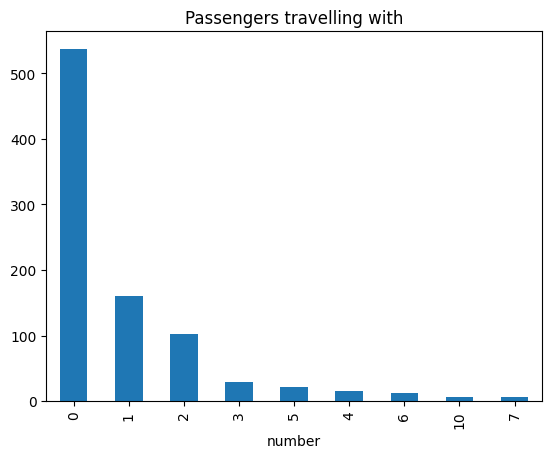

In [12]:
fig = df['number'].value_counts().plot.bar()
fig.set_title('Passengers travelling with')

In [13]:
# extract numerical part
df['number_numerical'] = pd.to_numeric(df["number"],errors='coerce',downcast='integer')

In [14]:
# extract categorical part
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)

df.head()

,Cabin,Ticket,SibSp,Parch,Survived,number,number_numerical,number_categorical
0,NaN,A/5 21171,1,0,0,1,1,NaN
1,C85,PC 17599,1,0,1,1,1,NaN
2,NaN,STON/O2. 3101282,0,0,1,0,0,NaN
3,C123,113803,1,0,1,1,1,NaN
4,NaN,373450,0,0,0,0,0,NaN


In [15]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [16]:
df['Ticket'].unique()

<StringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

In [17]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)') # captures numerical part
df['cabin_cat'] = df['Cabin'].str[0] # captures the first letter

df.head()

,Cabin,Ticket,SibSp,Parch,Survived,number,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,1,0,0,1,1,NaN,NaN,NaN
1,C85,PC 17599,1,0,1,1,1,NaN,85,C
2,NaN,STON/O2. 3101282,0,0,1,0,0,NaN,NaN,NaN
3,C123,113803,1,0,1,1,1,NaN,123,C
4,NaN,373450,0,0,0,0,0,NaN,NaN,NaN


<Axes: xlabel='cabin_cat'>

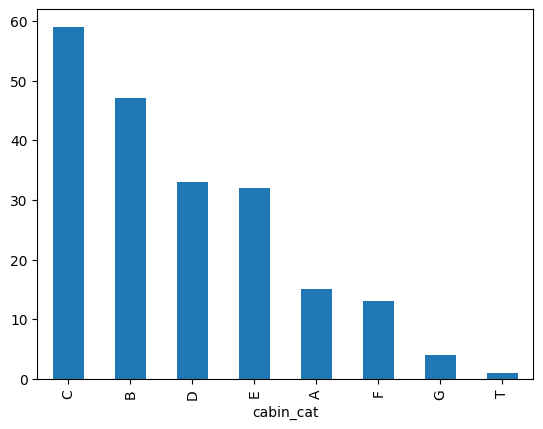

In [18]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [19]:
# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce',
                                   downcast='integer')

# extract the first part of ticket as category
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])

df.head(20)

,Cabin,Ticket,SibSp,Parch,Survived,number,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,1,0,0,1,1,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,1,0,1,1,1,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,0,0,1,0,0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,1,0,1,1,1,NaN,123,C,113803.0,NaN
4,NaN,373450,0,0,0,0,0,NaN,NaN,NaN,373450.0,NaN
5,NaN,330877,0,0,0,0,0,NaN,NaN,NaN,330877.0,NaN
6,E46,17463,0,0,0,0,0,NaN,46,E,17463.0,NaN
7,NaN,349909,3,1,0,4,4,NaN,NaN,NaN,349909.0,NaN
8,NaN,347742,0,2,1,2,2,NaN,NaN,NaN,347742.0,NaN
9,NaN,237736,1,0,1,1,1,NaN,NaN,NaN,237736.0,NaN


In [20]:
df['ticket_cat'].unique()

<StringArray>
[       'A/5',         'PC',   'STON/O2.',          nan,         'PP',
       'A/5.',       'C.A.',      'A./5.',   'SC/Paris',  'S.C./A.4.',
       'A/4.',         'CA',       'S.P.',     'S.O.C.',       'SO/C',
      'W./C.',   'SOTON/OQ',     'W.E.P.',     'STON/O',        'A4.',
          'C', 'SOTON/O.Q.',   'SC/PARIS',     'S.O.P.',       'A.5.',
         'Fa',        'CA.',       'LINE',     'F.C.C.',        'W/C',
      'SW/PP',      'SCO/W',       'P/PP',         'SC',      'SC/AH',
        'A/S',        'A/4',       'WE/P',    'S.W./PP',  'S.O./P.P.',
       'F.C.',   'SOTON/O2', 'S.C./PARIS', 'C.A./SOTON']
Length: 44, dtype: str